In [1]:
pip install pandas numpy openpyxl matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/bank-additional.csv', sep=';')

df.head()

Matplotlib is building the font cache; this may take a moment.


,",age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_"
0,"0,,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,tele..."
1,"1,57.0,services,MARRIED,high.school,,0.0,0.0,t..."
2,"2,37.0,services,MARRIED,high.school,0.0,1.0,0...."
3,"3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,tel..."
4,"4,56.0,services,MARRIED,high.school,0.0,0.0,1...."


In [5]:
df = pd.read_csv('../data/raw/bank-additional.csv')

df.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [6]:
df.shape

(43000, 24)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

In [8]:
df.isnull().sum()

Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [ ]:
df.describe()
# Datos númericos en el README con la unidad correcta

,Unnamed: 0,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


In [ ]:
# LIMPIEZA DE VALORES VACÍOS
# Columnas de texto rellenadas con 'unknown'
df['job'] = df['job'].fillna('unknown')
df['marital'] = df['marital'].fillna('unknown')
df['education'] = df['education'].fillna('unknown')

df.isnull().sum()

Unnamed: 0           0
age                  0
job                  0
marital              0
education            0
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [15]:
# Columnas 0/1 rellenadas con 0
df['default'] = df['default'].fillna(0)
df['housing'] = df['housing'].fillna(0)
df['loan'] = df['loan'].fillna(0)

df.isnull().sum()

Unnamed: 0           0
age                  0
job                  0
marital              0
education            0
default              0
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [16]:
# cons.price.idx y euribor3m son numéricas  a número y rellenamos con mediana
df['cons.price.idx'] = pd.to_numeric(df['cons.price.idx'], errors='coerce')
df['cons.price.idx'] = df['cons.price.idx'].fillna(df['cons.price.idx'].median())

df['euribor3m'] = pd.to_numeric(df['euribor3m'], errors='coerce')
df['euribor3m'] = df['euribor3m'].fillna(df['euribor3m'].median())

# date es texto con 'unknown'
df['date'] = df['date'].fillna('unknown')


df.isnull().sum()

Unnamed: 0            0
age                   0
job                   0
marital               0
education             0
default               0
housing               0
loan                  0
contact               0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
emp.var.rate          0
cons.price.idx    43000
cons.conf.idx         0
euribor3m             0
nr.employed           0
y                     0
date                  0
latitude              0
longitude             0
id_                   0
dtype: int64

In [17]:
df['cons.price.idx'].head(10)

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: cons.price.idx, dtype: float64

In [18]:
df = df.drop(columns=['cons.price.idx'])

df.isnull().sum()

Unnamed: 0       0
age              0
job              0
marital          0
education        0
default          0
housing          0
loan             0
contact          0
duration         0
campaign         0
pdays            0
previous         0
poutcome         0
emp.var.rate     0
cons.conf.idx    0
euribor3m        0
nr.employed      0
y                0
date             0
latitude         0
longitude        0
id_              0
dtype: int64

In [19]:
df = df.drop(columns=['Unnamed: 0'])

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'date', 'latitude', 'longitude', 'id_'],
      dtype='str')

In [21]:
df.to_csv('../data/processed/bank_limpio.csv', index=False)

In [ ]:
# Analizamos cuántos clientes de cada profesión contrataron el depósito 
df.groupby('job')['y'].value_counts()

job            y  
admin.         no     9458
               yes    1415
blue-collar    no     8989
               yes     665
entrepreneur   no     1396
               yes     126
housemaid      no     1012
               yes     111
management     no     2708
               yes     342
retired        no     1339
               yes     451
self-employed  no     1328
               yes     161
services       no     3826
               yes     336
student        no      620
               yes     283
technician     no     6264
               yes     762
unemployed     no      910
               yes     153
unknown        no      306
               yes      39
Name: count, dtype: int64

In [23]:
df.groupby('education')['y'].value_counts()

education            y  
basic.4y             no      3908
                     yes      448
basic.6y             no      2192
                     yes      194
basic.9y             no      5816
                     yes      493
high.school          no      8849
                     yes     1076
illiterate           no        14
                     yes        4
professional.course  no      4857
                     yes      620
university.degree    no     10974
                     yes     1748
unknown              no      1546
                     yes      261
Name: count, dtype: int64

In [24]:
#tasa de contratación del depósito según el nivel educativo
df.groupby('education')['y'].value_counts()

education            y  
basic.4y             no      3908
                     yes      448
basic.6y             no      2192
                     yes      194
basic.9y             no      5816
                     yes      493
high.school          no      8849
                     yes     1076
illiterate           no        14
                     yes        4
professional.course  no      4857
                     yes      620
university.degree    no     10974
                     yes     1748
unknown              no      1546
                     yes      261
Name: count, dtype: int64

In [25]:
# Calculamos el porcentaje real de contratación por nivel educativo
df.groupby('education')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).round(2)

education
basic.4y               10.28
basic.6y                8.13
basic.9y                7.81
high.school            10.84
illiterate             22.22
professional.course    11.32
university.degree      13.74
unknown                14.44
Name: y, dtype: float64

In [26]:
# Tasa de contratación según método de contacto
df.groupby('contact')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).round(2)

contact
cellular     14.74
telephone     5.16
Name: y, dtype: float64

In [27]:
# Edad media de los clientes que contrataron vs los que no contrataron
df.groupby('y')['age'].mean().round(2)

y
no     39.64
yes    40.54
Name: age, dtype: float64

In [28]:
# Creamos una nueva columna que clasifica a los clientes por franja de edad
def clasificar_edad(edad):
    if edad < 30:
        return 'joven'
    elif edad < 50:
        return 'adulto'
    else:
        return 'senior'

df['franja_edad'] = df['age'].apply(clasificar_edad)

df[['age', 'franja_edad']].head(10)

,age,franja_edad
0,38.0,adulto
1,57.0,senior
2,37.0,adulto
3,40.0,adulto
4,56.0,senior
5,45.0,adulto
6,59.0,senior
7,38.0,adulto
8,24.0,joven
9,25.0,joven


In [29]:
# Tasa de contratación del depósito por franja de edad
df.groupby('franja_edad')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).round(2)

franja_edad
adulto     9.64
joven     16.12
senior    14.48
Name: y, dtype: float64

In [ ]:
# Cargamos el archivo con detalles adicionales de los clientes
df_customers = pd.read_excel('../data/raw/customer-details.xlsx')

df_customers.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [31]:
# Unimos los dos datasets por el ID del cliente
df_merged = df.merge(df_customers, left_on='id_', right_on='ID')

df_merged.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,longitude,id_,franja_edad,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,38.0,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,adulto,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,0.0,0.0,0.0,telephone,149,1,...,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,senior,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,...,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,adulto,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,...,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,adulto,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,...,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,senior,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [32]:
# Ingresos medios de clientes que contrataron vs los que no contrataron
df_merged.groupby('y')['Income'].mean().round(2)

y
no     93132.52
yes    91805.23
Name: Income, dtype: float64

C:\Users\pablo\AppData\Local\Temp\ipykernel_5708\2949192679.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_por_profesion.index, y=tasa_por_profesion.values, palette='Blues_d')


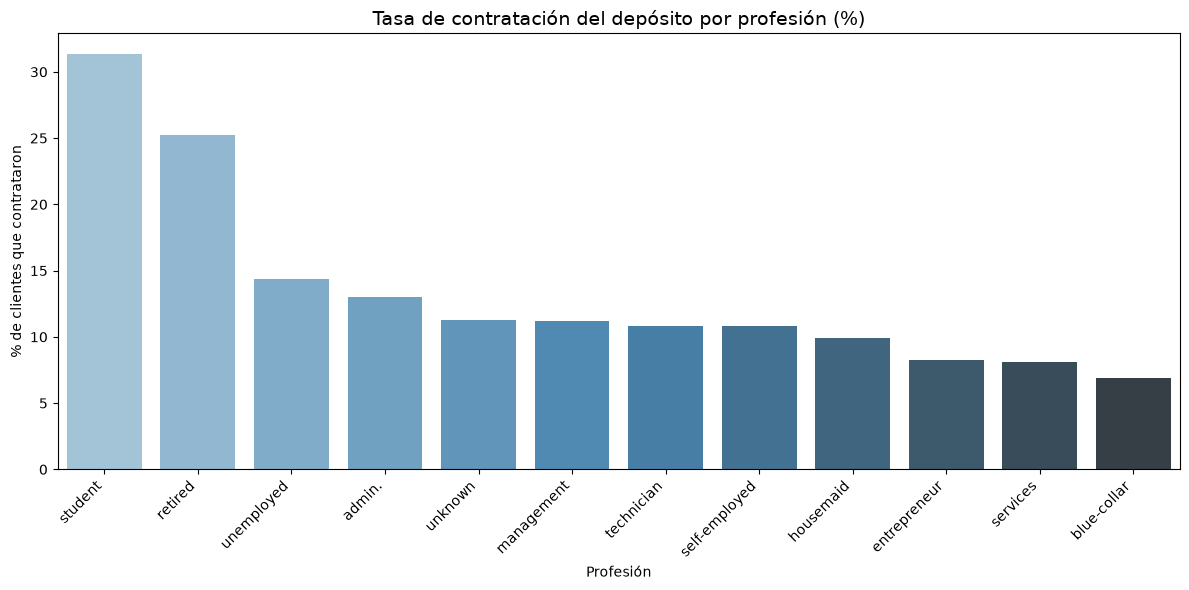

In [33]:
# Preparamos los datos para el gráfico
tasa_por_profesion = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).round(2).sort_values(ascending=False)

# Creamos el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x=tasa_por_profesion.index, y=tasa_por_profesion.values, palette='Blues_d')

plt.title('Tasa de contratación del depósito por profesión (%)', fontsize=14)
plt.xlabel('Profesión')
plt.ylabel('% de clientes que contrataron')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/tasa_contratacion_profesion.png')
plt.show()

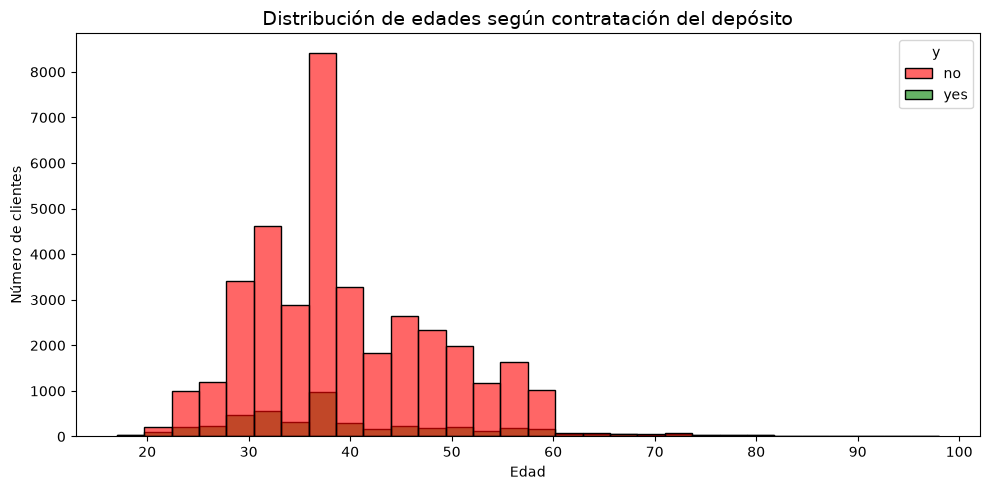

In [34]:
# Distribución de edades según si contrataron o no el depósito
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='y', bins=30, palette={'yes': 'green', 'no': 'red'}, alpha=0.6)

plt.title('Distribución de edades según contratación del depósito', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.savefig('../visualizations/distribucion_edades.png')
plt.show()

C:\Users\pablo\AppData\Local\Temp\ipykernel_5708\1074926836.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_contacto.index, y=tasa_contacto.values, palette='Greens_d')


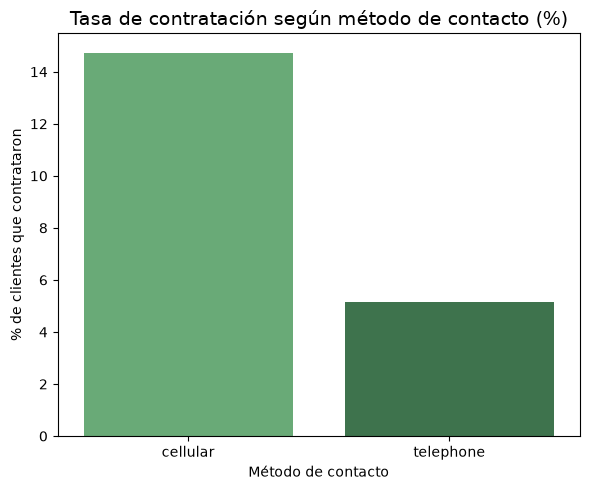

In [35]:
# Tasa de contratación según método de contacto
tasa_contacto = df.groupby('contact')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).round(2)

plt.figure(figsize=(6, 5))
sns.barplot(x=tasa_contacto.index, y=tasa_contacto.values, palette='Greens_d')

plt.title('Tasa de contratación según método de contacto (%)', fontsize=14)
plt.xlabel('Método de contacto')
plt.ylabel('% de clientes que contrataron')
plt.tight_layout()
plt.savefig('../visualizations/tasa_contacto.png')
plt.show()

In [36]:
# Guardamos el dataset combinado en processed
df_merged.to_csv('../data/processed/bank_merged.csv', index=False)